In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split 

from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import  confusion_matrix ,f1_score, balanced_accuracy_score
from sklearn.decomposition import PCA




In [23]:
df =pd.read_csv("cremad_features9.csv")

df

,0,1,2,3,4,5,6,7,8,9,...,334,335,336,337,338,339,340,341,label,file_path
0,-605.969473,62.950680,-93.763871,26.900366,-41.851416,-27.622412,-30.400918,-29.955055,-13.422597,-23.884569,...,15.969327,16.730202,147.535687,47.685252,0.014884,0.018921,0.220391,0.040403,angry,../AudioWAV/1001_DFA_ANG_XX.wav
1,-658.330873,72.456618,-111.255953,39.142658,-45.586311,-28.565146,-31.109795,-30.711459,-18.218380,-27.216534,...,13.073152,13.368537,158.763982,59.807452,0.005358,0.006402,0.236321,0.038060,disgust,../AudioWAV/1001_DFA_DIS_XX.wav
2,-607.645524,53.193578,-80.386056,21.895462,-29.064616,-28.821507,-22.227244,-21.024241,-13.015808,-20.227973,...,16.052877,16.052131,189.489266,65.310717,0.016163,0.023478,0.224925,0.032608,fear,../AudioWAV/1001_DFA_FEA_XX.wav
3,-602.868722,63.428998,-99.008455,32.712796,-38.372870,-32.311197,-27.256224,-26.796436,-17.542343,-27.284979,...,17.576548,15.599693,169.423500,51.595572,0.014575,0.017795,0.231329,0.036188,happy,../AudioWAV/1001_DFA_HAP_XX.wav
4,-639.967473,70.209821,-100.717441,31.484463,-41.721212,-28.617587,-27.084169,-34.017548,-16.977488,-26.729843,...,10.648724,10.803839,144.450017,49.128279,0.005738,0.007229,0.220909,0.038295,neutral,../AudioWAV/1001_DFA_NEU_XX.wav
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7437,-729.819969,71.680304,-84.012545,23.165694,-50.015410,-14.254647,-30.027998,-28.889671,-13.664884,-21.383050,...,9.392026,8.707355,177.955797,67.597764,0.001435,0.002109,0.203249,0.065209,disgust,../AudioWAV/1091_WSI_DIS_XX.wav
7438,-747.953847,73.534027,-91.769844,33.453402,-56.661419,-9.743267,-38.047669,-25.043334,-16.245686,-24.129208,...,11.090070,11.334273,143.724049,51.654521,0.001134,0.001415,0.220536,0.054538,fear,../AudioWAV/1091_WSI_FEA_XX.wav
7439,-686.622741,66.199999,-84.708953,27.341936,-51.682702,-22.606748,-28.762813,-28.922153,-11.478935,-21.093816,...,10.804501,10.726017,165.230586,53.109076,0.003113,0.003239,0.208151,0.071465,happy,../AudioWAV/1091_WSI_HAP_XX.wav
7440,-704.340416,66.488751,-75.856613,17.623534,-50.815997,-16.597358,-25.295541,-29.069410,-9.337423,-19.325773,...,11.970043,11.005015,179.194984,55.969099,0.002624,0.004785,0.206215,0.064503,neutral,../AudioWAV/1091_WSI_NEU_XX.wav


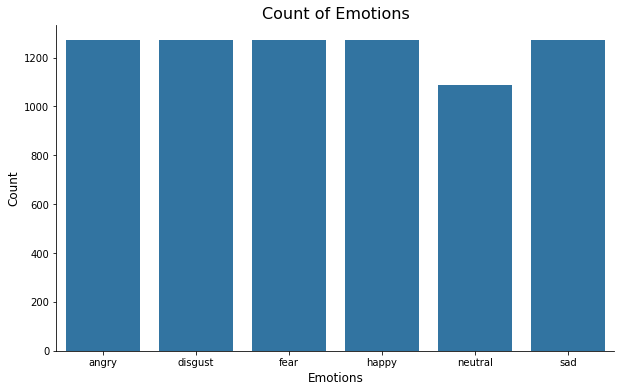

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6)) 
plt.title('Count of Emotions', size=16)
sns.countplot(x='label', data=df) 
plt.ylabel('Count', size=12)
plt.xlabel('Emotions', size=12)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.show()

In [25]:
df["label"] = df["label"].map({
    "angry": 0,
    "disgust": 1,
    "fear": 5,
    "sad": 3,
    "neutral": 4,
    "happy": 2,
})

df =df[df["label"]!=5]


In [26]:
x =df.drop(["label" ,"file_path"] ,axis =1)
y =df["label"]
x_train , x_test ,y_train ,y_test =train_test_split(x ,y ,test_size=0.1 ,random_state=42 ,stratify=y)

In [27]:
scaler_x = StandardScaler()
x_train = scaler_x.fit_transform(x_train)
x_test = scaler_x.transform(x_test)

In [28]:
# 95  -> 53 , 50
# 99 -> 54 ,50
pca = PCA(n_components=0.99)
x_train = pca.fit_transform(x_train)
x_test  = pca.transform(x_test)


In [29]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        64, activation="relu",
        kernel_regularizer=tf.keras.regularizers.L2(0.00005),
        input_shape=(x_train.shape[1],)
    ),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(
        32, activation="relu",
        kernel_regularizer=tf.keras.regularizers.L2(0.00001)
    ),

    tf.keras.layers.Dense(
        32, activation="relu",
        kernel_regularizer=tf.keras.regularizers.L2(0.00001)
    ),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(
        16, activation="relu"
    ),

    tf.keras.layers.Dense(6, activation="softmax")
])



model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00052),loss="sparse_categorical_crossentropy" ,metrics=["accuracy"])

/home/malak/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

early_stop =tf.keras.callbacks.EarlyStopping(
    monitor ="val_loss",
    patience =10,
    restore_best_weights =True  
)

In [31]:
history =model.fit(x_train ,y_train ,epochs=500 ,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights, 
    callbacks=[early_stop],
    verbose=2)

Epoch 1/500
70/70 - 2s - 35ms/step - accuracy: 0.3158 - loss: 1.6351 - val_accuracy: 0.3708 - val_loss: 1.4077
Epoch 2/500
70/70 - 0s - 4ms/step - accuracy: 0.4009 - loss: 1.4001 - val_accuracy: 0.4779 - val_loss: 1.2541
Epoch 3/500
70/70 - 0s - 5ms/step - accuracy: 0.4430 - loss: 1.2905 - val_accuracy: 0.4707 - val_loss: 1.2140
Epoch 4/500
70/70 - 0s - 5ms/step - accuracy: 0.4764 - loss: 1.2441 - val_accuracy: 0.4887 - val_loss: 1.1801
Epoch 5/500
70/70 - 0s - 5ms/step - accuracy: 0.4975 - loss: 1.2017 - val_accuracy: 0.5095 - val_loss: 1.1698
Epoch 6/500
70/70 - 0s - 5ms/step - accuracy: 0.5137 - loss: 1.1696 - val_accuracy: 0.5239 - val_loss: 1.1442
Epoch 7/500
70/70 - 0s - 6ms/step - accuracy: 0.5230 - loss: 1.1469 - val_accuracy: 0.5365 - val_loss: 1.1252
Epoch 8/500
70/70 - 0s - 5ms/step - accuracy: 0.5441 - loss: 1.1144 - val_accuracy: 0.5491 - val_loss: 1.1238
Epoch 9/500
70/70 - 0s - 5ms/step - accuracy: 0.5513 - loss: 1.0908 - val_accuracy: 0.5581 - val_loss: 1.1109
Epoch 10/

In [32]:
val_loss, val_acc = model.evaluate(x_train, y_train)
print("Train Accuracy:", val_acc)
print("Train Loss:", val_loss)


174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6998 - loss: 0.8017
Train Accuracy: 0.6998019218444824
Train Loss: 0.8016961812973022


In [33]:
val_loss, val_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", val_acc)
print("Test Loss:", val_loss)



20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6003 - loss: 1.0110 
Test Accuracy: 0.6003236174583435
Test Loss: 1.011047124862671


In [34]:
y_pred = model.predict(x_test).argmax(axis=1)

print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Balanced Accuracy: 0.5978187305858558
Macro F1: 0.5951245894657511


In [35]:
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]


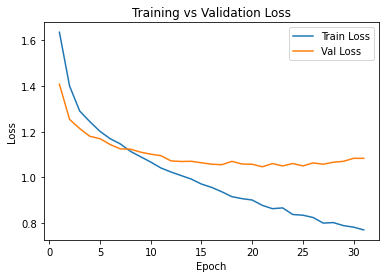

In [36]:
df_loss = pd.DataFrame({
    "Epoch": range(1, len(train_loss) + 1),
    "Train Loss": train_loss,
    "Validation Loss": val_loss
})

plt.figure(figsize=(6,4))
sns.lineplot(data=df_loss, x="Epoch", y="Train Loss", label="Train Loss")
sns.lineplot(data=df_loss, x="Epoch", y="Validation Loss", label="Val Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


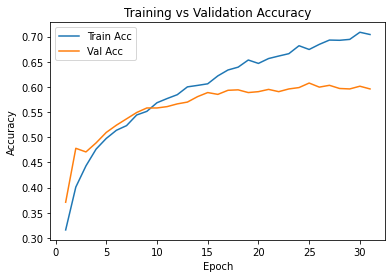

In [37]:
df_acc = pd.DataFrame({
    "Epoch": range(1, len(train_acc) + 1),
    "Train Accuracy": train_acc,
    "Validation Accuracy": val_acc
})

plt.figure(figsize=(6,4))
sns.lineplot(data=df_acc, x="Epoch", y="Train Accuracy", label="Train Acc")
sns.lineplot(data=df_acc, x="Epoch", y="Validation Accuracy", label="Val Acc")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


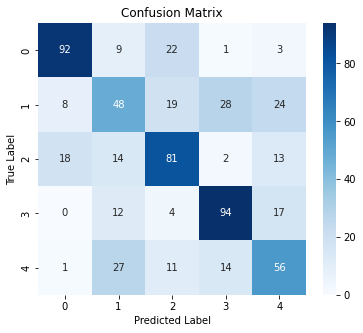

In [38]:

y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = y_test


cm = confusion_matrix(y_true, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


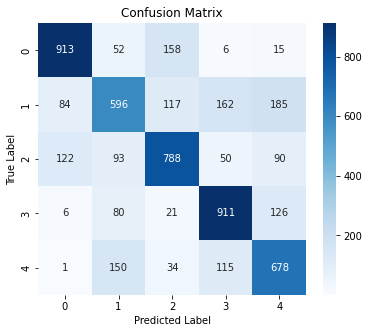

In [39]:

y_train_prob = model.predict(x_train)
y_pred = np.argmax(y_train_prob, axis=1)

y_true = y_train

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
